# Graph Neural Network


<b> Objective: </b>
Test whether a learned aggregation over the neighbourhood beats the hand-specified KNN columns

----------------------

<i><b>Author: </b> Salvador Palma <br>
<b>Institution: </b> Copenhagen University </i>

In [3]:
#Colab has torch already; torch_geometric needs installing on a fresh runtime
!pip install -q torch_geometric

### Imports

In [4]:
import sys
import os
COLAB_SESSION = True

if COLAB_SESSION:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_PATH = "/content/drive/MyDrive/UCPH/POOCS/"
    sys.path.insert(0, DRIVE_PATH)      # so GreenlandUtils.py is importable
else:
    DRIVE_PATH = ""

import pandas as pd
import numpy as np
import warnings
import json
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

import torch
import torch.nn as nn
from torch_geometric.nn import SAGEConv, GATConv

from GreenlandUtils import lonlatToUTM24N, Split, MostCommonElements, Printable

torch.manual_seed(42)
np.random.seed(42)

#Colab with a GPU runtime picks this up automatically; locally it falls back to CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__}   device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   {torch.cuda.get_device_name(0)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
torch 2.11.0+cu128   device: cuda
   Tesla T4


### Setup

Reads the same `Data.csv`, the same folds and the same column schema as the regressor
notebook, so the two sets of numbers are directly comparable.

To run on Colab with a GPU runtime, set `COLAB_SESSION = True` above and mirror these under
`DRIVE_PATH` on Drive:

```
GreenlandUtils.py
Data/<source>.json
Data/<DATA_TYPE>/<MERGE_TYPE>/Data.csv
Data/<DATA_TYPE>/<MERGE_TYPE>/5-Fold.kfold
Results/<DATA_TYPE>/<MERGE_TYPE>/          (for the baseline and KNN C json to compare against)
```

In [5]:
DATA_TYPE = "Stream Sediment"
MERGE_TYPE = "Mean Merge"
SOURCE_CSV = "stream-sediment"

DATA_PATH = f"Data/{DATA_TYPE}/{MERGE_TYPE}/"
RESULTS_PATH = f"Results/{DATA_TYPE}/{MERGE_TYPE}/"
os.makedirs(f"{DRIVE_PATH}{RESULTS_PATH}", exist_ok=True)


def ReadColumnSchema(baseName: str) -> dict:
    with open(f"{DRIVE_PATH}Data/{baseName}.json", "r") as f:
        return json.load(f)

def ReadDataFrame(path: str, baseName: str) -> pd.DataFrame:
    return pd.read_csv(f"{DRIVE_PATH}{path}{baseName}.csv", delimiter=";")

def ReadKFold(path: str, baseName: str, df: pd.DataFrame) -> list[Split]:
    with open(f"{DRIVE_PATH}{path}{baseName}.kfold", "r") as f:
        json_result = json.load(f)

    return [Split({name: df.loc[idx] for name, idx in json_result[key].items()}) for key in sorted(json_result, key=int)]

def SaveResults(results: dict, path: str, baseName: str):
    for _, score in results.items():
        if "y_pred" in score:
            score["y_pred"] = score["y_pred"].tolist() if not isinstance(score["y_pred"], list) else score["y_pred"]
        if "y_test" in score:
            score["y_test"] = score["y_test"].tolist() if not isinstance(score["y_test"], list) else score["y_test"]

    with open(f"{DRIVE_PATH}{path}{baseName}.json", "w") as f:
        json.dump(results, f, indent=4)

def LoadResults(path: str, baseName: str) -> dict:
    results = None
    try:
        with open(f"{DRIVE_PATH}{path}{baseName}.json", "r") as f:
            results = json.load(f)
    except FileNotFoundError:
        print(f"File not found: {DRIVE_PATH}{path}{baseName}.json")
    return results

def AggregateFolds(kfoldResults: dict):
    aggregated = {}

    for element, folds in kfoldResults.items():
        valid = [s for s in folds.values() if s["r2"] is not None and not np.isnan(s["r2"])]
        if not valid:
            aggregated[element] = { "r2": None, "mae": None }
            continue

        aggregated[element] = {
            "r2": float(np.mean([s["r2"] for s in valid])),
            "r2_std": float(np.std([s["r2"] for s in valid])),
            "mae": float(np.mean([s["mae"] for s in valid])),
        }

    return aggregated


df = ReadDataFrame(DATA_PATH, "Data")
kfold_splits = ReadKFold(DATA_PATH, "5-Fold", df)

schema = ReadColumnSchema(SOURCE_CSV)
sampleCol = schema["sampleCol"]
metaCols = schema["metaCols"]
physicalCols = schema["physicalCols"]
locationCols = schema["locationCols"]

elementCols = [col for col in df.columns if col not in metaCols + physicalCols]

MIN_COVERAGE = 10
coverage = df[elementCols].notna().sum()
elementCols = [col for col in elementCols if coverage[col] >= MIN_COVERAGE]

mostCommonElements = [element for element, _ in MostCommonElements(df, elementCols, top_n=10)]

print(f"Samples: {len(df)}   Elements: {len(elementCols)}   Folds: {len(kfold_splits)}")
print(f"Targets: {mostCommonElements}")

/tmp/ipykernel_1977/1263571834.py:15: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(f"{DRIVE_PATH}{path}{baseName}.csv", delimiter=";")
Analyzing Elements: 100%|██████████| 87/87 [00:00<00:00, 6264.99it/s]

Samples: 17463   Elements: 87   Folds: 5
Targets: ['Zn ppm', 'U ppm', 'Cu ppm', 'Rb ppm', 'Ba ppm', 'Cr ppm', 'Sr ppm', 'Fe %', 'V ppm', 'Co ppm']


### Building the Graph

One node per sample. Edges join a sample to its `k` nearest **training** neighbours, exactly
the mapping the KNN variants use, so the graph the network sees is the same neighbourhood the
hand-built columns saw.

Two things the KNN columns could not carry:

* **Edge distance.** Variants A to D treat a neighbour 300 m away and one 15 km away
  identically. Here the distance rides on the edge, so the network can learn to discount a far
  neighbour instead of averaging it in blindly.
* **Learned aggregation.** Variant C averages; the network chooses how to weight.

Node features are the sample's own elements with the target masked out, plus a missingness
indicator per element. NaN is not a value a network can consume, so each element becomes two
numbers: the standardised value (zero when absent) and a flag saying whether it was there.

In [6]:
def ProjectedCoords(df: pd.DataFrame, lonCol: str = "Longitude", latCol: str = "Latitude") -> np.ndarray:
    x, y = lonlatToUTM24N(df[lonCol].to_numpy(dtype=float), df[latCol].to_numpy(dtype=float))
    return np.column_stack([x, y])


def BuildNeighbourMapping(df: pd.DataFrame, split: Split, k: int = 20, excludeSameLocation: bool = False) -> tuple[np.ndarray, np.ndarray]:
    """Identical to the regressor notebook: neighbours come from the training rows only."""

    allCoords = ProjectedCoords(df)
    trainPos = df.index.get_indexer(split.data["train"].index)
    trainCoords = allCoords[trainPos]

    padding = int(df.groupby(["Longitude", "Latitude"]).size().max()) if excludeSameLocation else 1
    nNeighbours = min(k + padding, len(trainPos))

    tree = NearestNeighbors(n_neighbors=nNeighbours).fit(trainCoords)
    distances, positions = tree.kneighbors(allCoords)
    neighbourPos = trainPos[positions]

    rejected = neighbourPos == np.arange(len(df))[:, None]
    if excludeSameLocation:
        rejected |= distances == 0

    distances = np.where(rejected, np.inf, distances)
    ordered = np.argsort(distances, axis=1)[:, :k]

    return np.take_along_axis(neighbourPos, ordered, axis=1), np.take_along_axis(distances, ordered, axis=1)


def BuildEdges(neighbourPos: np.ndarray, neighbourDist: np.ndarray, k: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Directed edges neighbour -> sample, carrying log distance in km as the edge feature."""

    source = neighbourPos[:, :k].ravel()
    target = np.repeat(np.arange(len(neighbourPos)), k)
    distance = neighbourDist[:, :k].ravel()

    #A sample with fewer than k reachable neighbours keeps infinite distances, so drop those
    usable = np.isfinite(distance)

    edgeIndex = torch.tensor(np.vstack([source[usable], target[usable]]), dtype=torch.long, device=DEVICE)

    #Log scale because neighbour distance spans metres to tens of km
    edgeAttr = torch.tensor(np.log1p(distance[usable] / 1000.0), dtype=torch.float32, device=DEVICE).unsqueeze(1)

    return edgeIndex, edgeAttr


def BuildNodeFeatures(df: pd.DataFrame, elementCols: list[str], element: str, trainPos: np.ndarray) -> tuple[torch.Tensor, torch.Tensor]:
    """Own chemistry with the target removed, standardised on the training rows only.

    Each element contributes two columns: the value (zero when missing) and a present flag,
    so the network can tell "average" apart from "not measured".
    """

    featureCols = [col for col in elementCols if col != element]
    values = df[featureCols].to_numpy(dtype=float)

    #Statistics come from the training rows so a test sample never informs the scaling
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        centre = np.nanmean(values[trainPos], axis=0)
        spread = np.nanstd(values[trainPos], axis=0)

    spread = np.where((spread == 0) | ~np.isfinite(spread), 1.0, spread)
    centre = np.where(np.isfinite(centre), centre, 0.0)

    present = np.isfinite(values).astype(np.float32)
    scaled = np.where(np.isfinite(values), (values - centre) / spread, 0.0)

    x = torch.tensor(np.hstack([scaled, present]), dtype=torch.float32, device=DEVICE)
    y = torch.tensor(df[element].to_numpy(dtype=float), dtype=torch.float32, device=DEVICE)

    return x, y


neighbourPos, neighbourDist = BuildNeighbourMapping(df, kfold_splits[0], k=20, excludeSameLocation=True)
edgeIndex, edgeAttr = BuildEdges(neighbourPos, neighbourDist, k=10)

printable = Printable()
printable.title("Graph")
printable.add("Nodes", len(df))
printable.add("Edges", edgeIndex.shape[1])
printable.add("Edge feature", "log1p(distance km)")
printable.rest()
printable.add("Distance median", f"{np.median(neighbourDist[:, :10])/1000:.3f} km")
printable.add("Distance p95", f"{np.percentile(neighbourDist[:, :10], 95)/1000:.3f} km")
printable.flush()

=============== Graph ===============
Nodes:             17463
Edges:             174630
Edge feature:      log1p(distance km)


Distance median:   4.583 km
Distance p95:      14.233 km


### The Network

Two message-passing layers over the neighbourhood, then a head that combines the aggregated
neighbourhood with the node's own chemistry.

`GATConv` with `edge_dim=1` is what makes this more than variant C: attention weights are
computed per edge *from the distance*, so the network learns how quickly a neighbour stops
mattering rather than being told to average the nearest k. `SAGEConv` is kept as the
distance-blind control — the difference between the two is the whole question.

In [7]:
class GeoGNN(nn.Module):
    """Message passing over the neighbour graph, concatenated with the node's own features."""

    def __init__(self, inputDim: int, hiddenDim: int = 64, layerType: str = "gat", heads: int = 4, dropout: float = 0.1):
        super().__init__()

        self.layerType = layerType

        if layerType == "gat":
            #edge_dim lets attention read the distance, which is the point of the exercise
            self.conv1 = GATConv(inputDim, hiddenDim // heads, heads=heads, edge_dim=1, dropout=dropout)
            self.conv2 = GATConv(hiddenDim, hiddenDim // heads, heads=heads, edge_dim=1, dropout=dropout)
        else:
            self.conv1 = SAGEConv(inputDim, hiddenDim)
            self.conv2 = SAGEConv(hiddenDim, hiddenDim)

        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        #The node keeps a direct path to the head, so the graph only has to add what it knows
        self.head = nn.Sequential(
            nn.Linear(hiddenDim + inputDim, hiddenDim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hiddenDim, 1),
        )

    def forward(self, x, edgeIndex, edgeAttr):
        if self.layerType == "gat":
            hidden = self.activation(self.conv1(x, edgeIndex, edge_attr=edgeAttr))
            hidden = self.dropout(hidden)
            hidden = self.activation(self.conv2(hidden, edgeIndex, edge_attr=edgeAttr))
        else:
            hidden = self.activation(self.conv1(x, edgeIndex))
            hidden = self.dropout(hidden)
            hidden = self.activation(self.conv2(hidden, edgeIndex))

        return self.head(torch.cat([hidden, x], dim=1)).squeeze(-1)


def R2Score(yTrue: torch.Tensor, yPred: torch.Tensor) -> float:
    ssRes = torch.sum((yTrue - yPred) ** 2)
    ssTot = torch.sum((yTrue - yTrue.mean()) ** 2)
    return float(1 - ssRes / ssTot) if ssTot > 0 else float("nan")

### Training

Full-batch transductive training: the whole graph is passed forward every epoch, but the loss
only ever sees training nodes. Test nodes contribute their features to their neighbours, which
is the normal transductive setting and matches how the KNN columns were built — a test sample's
own chemistry was always available there too.

The validation split is carved out of the training nodes, never from test, and is used only to
keep the best epoch.

In [8]:
def TrainGNN(df: pd.DataFrame, split: Split, element: str, elementCols: list[str], edgeIndex: torch.Tensor, edgeAttr: torch.Tensor, layerType: str = "gat", hiddenDim: int = 64, epochs: int = 1000, learningRate: float = 0.01, patience: int = 60, verbose: bool = False):

    trainPos = df.index.get_indexer(split.data["train"].index)
    testPos = df.index.get_indexer(split.data["test"].index)

    x, y = BuildNodeFeatures(df, elementCols, element, trainPos)

    #Only nodes where the target was actually measured can be scored
    measured = torch.isfinite(y)
    trainMask = torch.zeros(len(df), dtype=torch.bool, device=DEVICE); trainMask[trainPos] = True
    testMask = torch.zeros(len(df), dtype=torch.bool, device=DEVICE); testMask[testPos] = True
    trainMask &= measured
    testMask &= measured

    if trainMask.sum() < 50 or testMask.sum() < 5:
        return { "r2": None, "mae": None }

    #A slice of train is held back to pick the epoch, so test is never looked at during fitting
    trainIdx = trainMask.nonzero(as_tuple=True)[0]
    shuffled = trainIdx[torch.randperm(len(trainIdx), generator=torch.Generator().manual_seed(42)).to(DEVICE)]
    validIdx = shuffled[: max(1, len(shuffled) // 10)]
    fitIdx = shuffled[max(1, len(shuffled) // 10) :]

    yFilled = torch.nan_to_num(y, nan=0.0)

    model = GeoGNN(x.shape[1], hiddenDim=hiddenDim, layerType=layerType).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=learningRate, weight_decay=1e-4)
    lossFunction = nn.MSELoss()

    bestValid, bestState, waited = float("inf"), None, 0

    for epoch in range(epochs):
        model.train()
        optimiser.zero_grad()
        prediction = model(x, edgeIndex, edgeAttr)
        loss = lossFunction(prediction[fitIdx], yFilled[fitIdx])
        loss.backward()
        optimiser.step()

        model.eval()
        with torch.no_grad():
            prediction = model(x, edgeIndex, edgeAttr)
            validLoss = float(lossFunction(prediction[validIdx], yFilled[validIdx]))

        if validLoss < bestValid - 1e-5:
            bestValid, waited = validLoss, 0
            bestState = {key: value.clone() for key, value in model.state_dict().items()}
        else:
            waited += 1
            if waited >= patience:
                break

        if verbose and epoch % 50 == 0:
            print(f"   epoch {epoch:>4}  train {float(loss):.4f}  valid {validLoss:.4f}")

    if bestState is not None:
        model.load_state_dict(bestState)

    model.eval()
    with torch.no_grad():
        prediction = model(x, edgeIndex, edgeAttr)

    yTrue = yFilled[testMask]
    yPred = prediction[testMask]

    return {
        "r2": R2Score(yTrue, yPred),
        "mae": float(torch.mean(torch.abs(yTrue - yPred))),
        "epochs": epoch + 1,
    }

In [9]:
def TrainAllElementsKFoldGNN(df: pd.DataFrame, kfold_splits: list[Split], elementsToTrain: list[str], elementCols: list[str]=None, k: int=10, layerType: str="gat", excludeSameLocation: bool=True, **kwargs):

    results = {element: {} for element in elementsToTrain}

    #The graph depends on the fold, so it is built once per fold and reused by every element
    for foldIdx, split in enumerate(tqdm(kfold_splits, desc=f"Folds ({layerType})")):

        neighbourPos, neighbourDist = BuildNeighbourMapping(df, split, k=k, excludeSameLocation=excludeSameLocation)
        edgeIndex, edgeAttr = BuildEdges(neighbourPos, neighbourDist, k)

        for element in elementsToTrain:
            results[element][foldIdx] = TrainGNN(df, split, element, elementCols, edgeIndex, edgeAttr, layerType=layerType, **kwargs)

    return results


GNN_VARIANTS = { "GAT": "gat", "SAGE": "sage" }
GNN_K = 10

results_gnn = {}

for name, layerType in GNN_VARIANTS.items():
    baseName = f"GNN_{name}_KFold_k{GNN_K}"

    results_gnn[name] = LoadResults(RESULTS_PATH, baseName)
    if results_gnn[name] is None:
        raw = TrainAllElementsKFoldGNN(df, kfold_splits, mostCommonElements, elementCols, k=GNN_K, layerType=layerType)
        results_gnn[name] = AggregateFolds(raw)
        SaveResults(results_gnn[name], RESULTS_PATH, baseName)

    print(f"{name:<6} ready")

File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Stream Sediment/Mean Merge/GNN_GAT_KFold_k10.json


Folds (gat): 100%|██████████| 5/5 [15:58<00:00, 191.69s/it]


GAT    ready
File not found: /content/drive/MyDrive/UCPH/POOCS/Results/Stream Sediment/Mean Merge/GNN_SAGE_KFold_k10.json


Folds (sage): 100%|██████████| 5/5 [04:31<00:00, 54.25s/it]

SAGE   ready


### Results

The comparison that matters is against the numbers already in `Results/`: the plain regressor
baseline (own chemistry, no neighbourhood) and the best hand-built KNN variant. The GNN has to
beat the second to have earned its place, not merely the first.

In [10]:
MODEL_NAMES = { "rf": "RandomForest", "hgb": "HistGradientBoosting", "xgb": "XGBoost" }
MODEL_TYPE = "hgb"


def ReportGNN(gnnResults: dict[str, dict], elements: list[str]):

    #Pulled off disk so the GNN is scored against exactly the numbers already reported
    reference = {
        "Baseline (no neighbours)": LoadResults(RESULTS_PATH, f"{MODEL_NAMES[MODEL_TYPE]}_KFold"),
        "KNN C (hand-built)": LoadResults(RESULTS_PATH, f"{MODEL_NAMES[MODEL_TYPE]}_KFold_KNN_C_ExcludingColocation"),
    }

    allResults = { name: results for name, results in reference.items() if results is not None }
    allResults.update({ f"GNN {name}": results for name, results in gnnResults.items() })

    baselineScore = np.mean([s["r2"] for s in allResults["Baseline (no neighbours)"].values() if s["r2"] is not None])

    printable = Printable()
    printable.title("Mean R2")
    for name, results in allResults.items():
        scores = [s["r2"] for s in results.values() if s["r2"] is not None]
        spreads = [s["r2_std"] for s in results.values() if s.get("r2_std") is not None]
        printable.add(name, f"R2: {np.mean(scores):.4f} +/- {np.mean(spreads):.4f}   vs baseline: {np.mean(scores) - baselineScore:>+7.4f}")

    printable.rest()
    printable.title("Per Element")
    printable.add("element", " ".join(f"{name[:13]:>13}" for name in allResults))
    for element in elements:
        cells = []
        for name in allResults:
            score = allResults[name].get(element, {}).get("r2")
            cells.append(f"{score:>13.3f}" if score is not None else f"{'-':>13}")
        printable.add(element, " ".join(cells))

    printable.flush()

    return allResults


allResults = ReportGNN(results_gnn, mostCommonElements)

============================== Mean R2 ==============================
Baseline (no neighbours):   R2: 0.7988 +/- 0.0119   vs baseline: +0.0000
KNN C (hand-built):         R2: 0.8285 +/- 0.0085   vs baseline: +0.0297
GNN GAT:                    R2: 0.8226 +/- 0.0104   vs baseline: +0.0238
GNN SAGE:                   R2: 0.8225 +/- 0.0109   vs baseline: +0.0237


============================== Per Element ==============================
element:                    Baseline (no  KNN C (hand-b       GNN GAT      GNN SAGE
Zn ppm:                             0.781         0.807         0.796         0.807
U ppm:                              0.594         0.800         0.816         0.807
Cu ppm:                             0.817         0.832         0.825         0.824
Rb ppm:                             0.873         0.878         0.874         0.876
Ba ppm:                             0.783         0.794         0.777         0.775
Cr ppm:                             0.790         0.794   

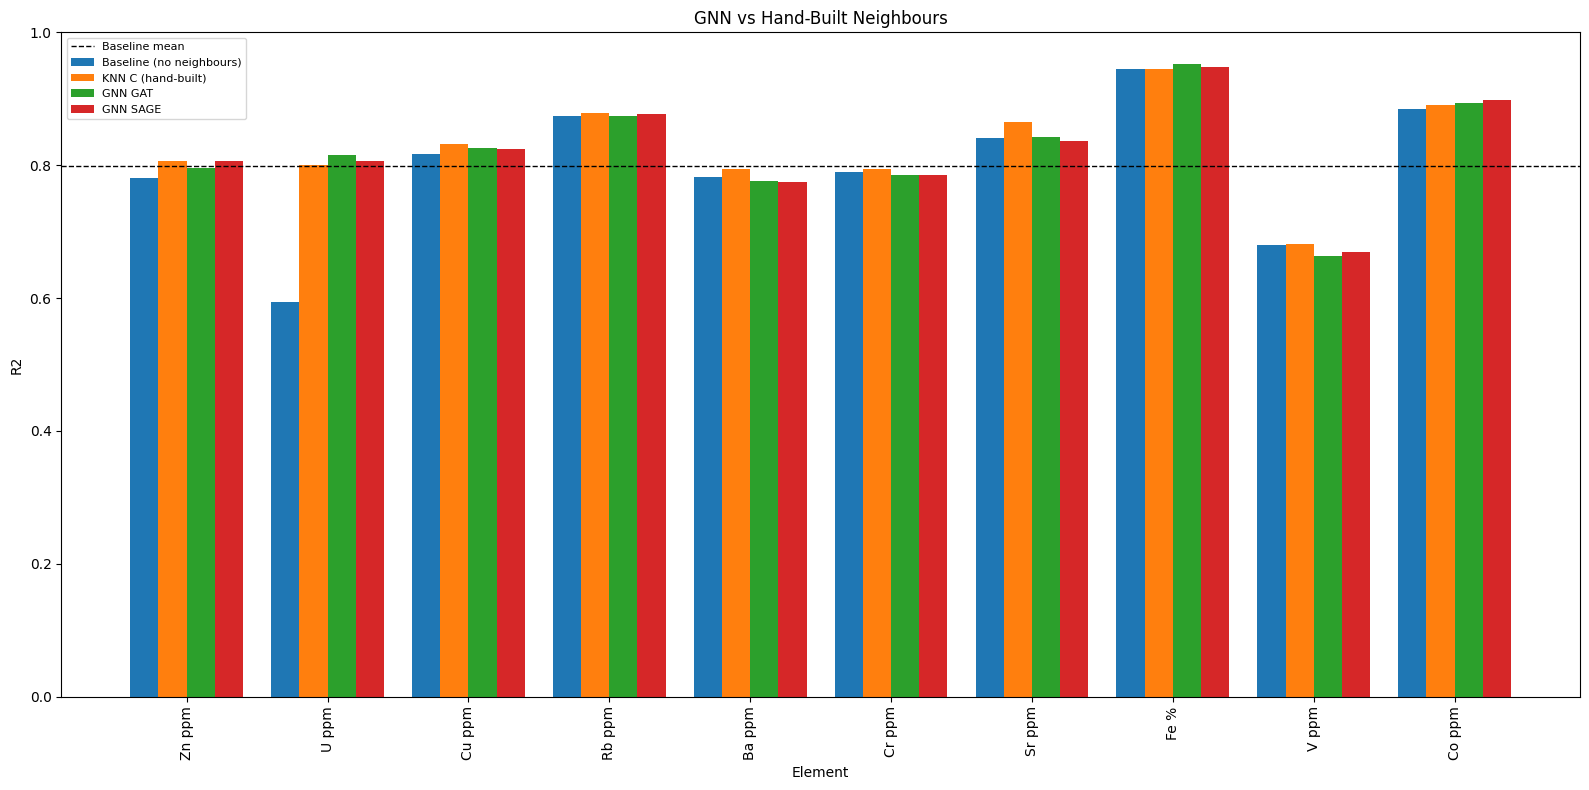

In [11]:
def DisplayGNNGraph(allResults: dict[str, dict], elements: list[str], title: str = "GNN vs Hand-Built Neighbours"):

    names = list(allResults)
    x = np.arange(len(elements))
    width = 0.8 / len(names)

    fig, ax = plt.subplots(figsize=(16, 8))

    for i, name in enumerate(names):
        values = [allResults[name].get(element, {}).get("r2") or 0 for element in elements]
        offset = (i - (len(names) - 1) / 2) * width
        ax.bar(x + offset, values, width, label=name)

    baselineScore = np.mean([s["r2"] for s in allResults["Baseline (no neighbours)"].values() if s["r2"] is not None])
    ax.axhline(baselineScore, color="black", linestyle="--", linewidth=1, label="Baseline mean")

    ax.set_xlabel("Element")
    ax.set_ylabel("R2")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(elements, rotation=90)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


DisplayGNNGraph(allResults, mostCommonElements)